# MAPF-LNS run variability

For each case study, compute one non-anytime LaCAM solution and improve that exact incumbent with ten 100-second MAPF-LNS runs at neighbourhood size 4. Curves show individual runs and their mean SoD/LB improvement.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed

from mapf_anytime.problem import MapfProblem
from mapf_anytime.solvers import LaCAMConfig, LNSConfig, run_lacam, run_lns

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
CASE_STUDIES = ROOT / "datasets/movingai/case_studies"
MANIFESTS = sorted(CASE_STUDIES.glob("*.json"))
assert len(MANIFESTS) == 4, f"Expected four case studies, found {len(MANIFESTS)}"
LACAM_TIMEOUT = 40
LACAM_SEED = 0
LNS_TIMEOUT = 100
LNS_SEEDS = range(10)
WORKERS = 10
NEIGHBOURHOOD_SIZE = 4
REPLAN_TIME_LIMIT = 10.0

In [ ]:
problems, incumbents, lower_bounds, initial_rows = {}, {}, {}, []
for manifest in MANIFESTS:
    problem = MapfProblem.from_manifest(manifest)
    instance_id = problem.name
    lower_bound = json.loads(manifest.read_text())["lower_bound_soc"]
    result = run_lacam(
        problem, LaCAMConfig(LACAM_TIMEOUT, anytime=False, seed=LACAM_SEED)
    )
    if result.solution is None:
        raise RuntimeError(result.error or f"LaCAM failed on {instance_id}: {result.status}")
    problems[instance_id] = problem
    incumbents[instance_id] = result.solution
    lower_bounds[instance_id] = lower_bound
    initial_rows.append({
        "instance_id": instance_id,
        "agents": problem.agents, "LaCAM runtime (s)": result.wall_seconds,
        "initial SOC": result.solution.soc(),
        "lower bound SOC": lower_bound,
    })
display(pd.DataFrame(initial_rows).round(3))

,instance_id,agents,LaCAM runtime (s),initial SOC,lower bound SOC
0,maze-32-32-2__high,200,0.177,27848,10795
1,maze-32-32-2__low,33,0.026,1933,1751
2,warehouse-10-20-10-2-1__medium,570,1.200,62998,45629
3,warehouse-20-40-10-2-1__low,1130,5.164,212259,188529


In [ ]:
def improvement_curve(initial_soc, lower_bound, trace):
    points = iter(sorted((point.seconds, point.soc) for point in trace))
    point = next(points, None)
    best, curve = initial_soc, []
    for second in range(LNS_TIMEOUT + 1):
        while point is not None and point[0] <= second:
            best = min(best, point[1])
            point = next(points, None)
        curve.append((initial_soc - best) / lower_bound)
    return curve

def run_case(instance_id, seed):
    problem, incumbent = problems[instance_id], incumbents[instance_id]
    result = run_lns(
        problem, incumbent,
        LNSConfig(
            LNS_TIMEOUT, seed=seed, neighborhood_size=NEIGHBOURHOOD_SIZE,
            replan_time_limit=REPLAN_TIME_LIMIT, early_stop_seconds=None,
        ),
    )
    if result.status not in {"success", "timeout_with_incumbent"}:
        raise RuntimeError(result.error or f"LNS failed on {instance_id}: {result.status}")
    initial_soc = incumbent.soc()
    lower_bound = lower_bounds[instance_id]
    return {
        "instance_id": instance_id, "seed": seed,
        "status": result.status, "wall_seconds": result.wall_seconds,
        "final_improvement": (initial_soc - result.solution.soc()) / lower_bound,
        "curve": improvement_curve(initial_soc, lower_bound, result.trace),
    }

records = Parallel(n_jobs=WORKERS, backend="loky", verbose=10)(
    delayed(run_case)(problem.name, seed)
    for problem in problems.values()
    for seed in LNS_SEEDS
)
runs = pd.DataFrame(records).sort_values(["instance_id", "seed"]).reset_index(drop=True)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:  1.7min
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:  3.3min
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:  5.0min
[Parallel(n_jobs=10)]: Done  26 out of  40 | elapsed:  5.0min remaining:  2.7min
[Parallel(n_jobs=10)]: Done  31 out of  40 | elapsed:  6.7min remaining:  1.9min
[Parallel(n_jobs=10)]: Done  36 out of  40 | elapsed:  6.7min remaining:   44.4s
[Parallel(n_jobs=10)]: Done  40 out of  40 | elapsed:  6.7min finished


In [ ]:
display(runs.drop(columns="curve").round(4))
display(
    runs.groupby("instance_id").agg(
        improvement_mean=("final_improvement", "mean"),
        improvement_std=("final_improvement", "std"),
        runtime_mean_s=("wall_seconds", "mean"),
        runtime_std_s=("wall_seconds", "std"),
    ).round(4)
)

,instance_id,seed,status,wall_seconds,final_improvement
0,maze-32-32-2__high,0,success,99.5822,0.2473
1,maze-32-32-2__high,1,success,99.5498,0.2240
2,maze-32-32-2__high,2,success,99.5615,0.1923
3,maze-32-32-2__high,3,success,99.5663,0.1916
4,maze-32-32-2__high,4,success,99.5841,0.2472
5,maze-32-32-2__high,5,success,99.5538,0.2384
6,maze-32-32-2__high,6,success,99.5763,0.2083
7,maze-32-32-2__high,7,success,99.5667,0.2230
8,maze-32-32-2__high,8,success,99.6119,0.2280
9,maze-32-32-2__high,9,success,99.5965,0.2677


,improvement_mean,improvement_std,runtime_mean_s,runtime_std_s
instance_id,,,,
maze-32-32-2__high,0.2268,0.0246,99.5749,0.0194
maze-32-32-2__low,0.0541,0.0021,99.5799,0.0154
warehouse-10-20-10-2-1__medium,0.1967,0.0171,99.7185,0.1100
warehouse-20-40-10-2-1__low,0.0384,0.0064,100.5277,0.8745


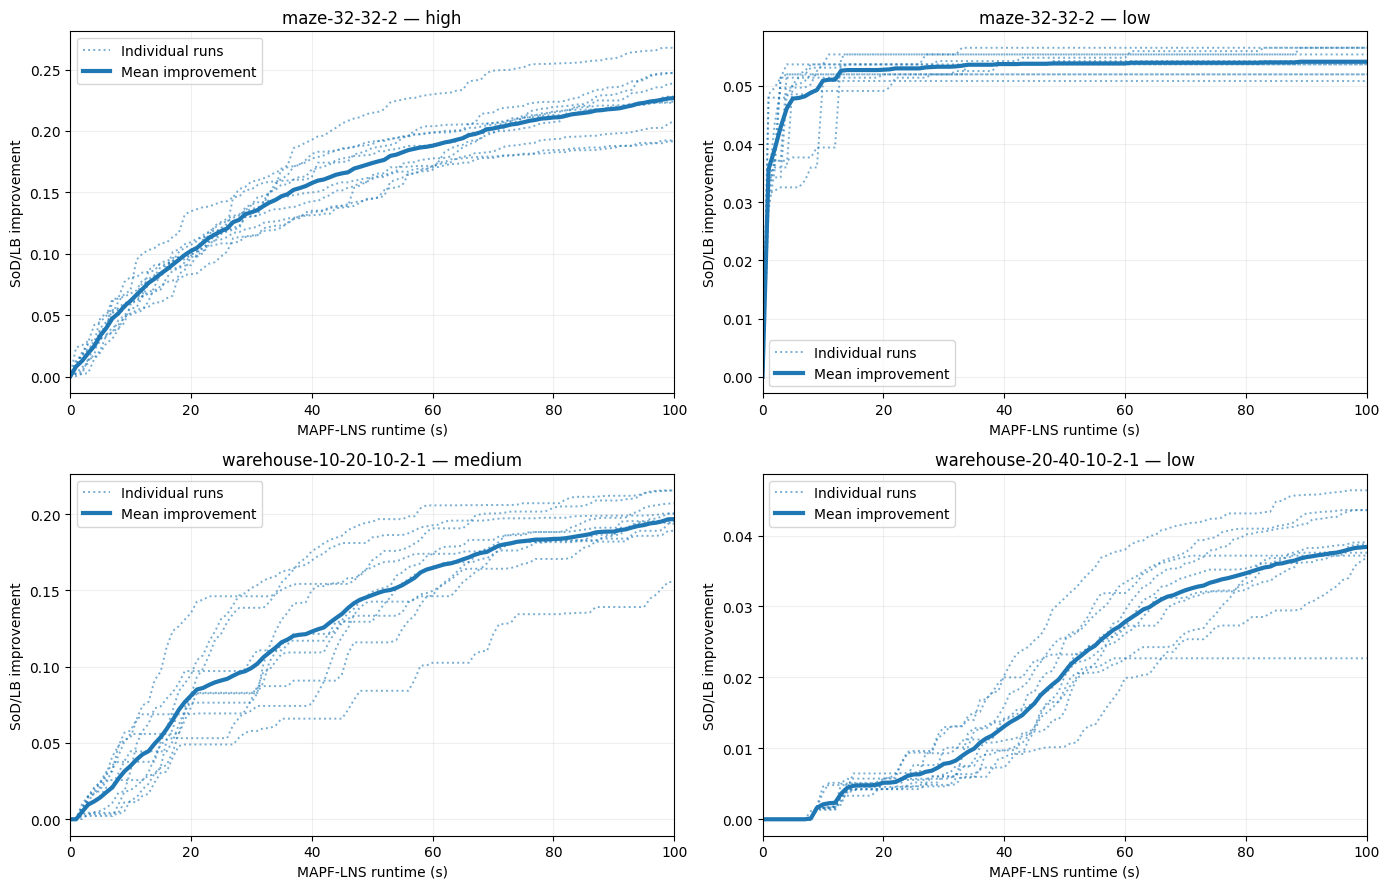

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
seconds = np.arange(LNS_TIMEOUT + 1)
for axis, manifest in zip(axes.flat, MANIFESTS):
    instance_id = manifest.stem
    curves = np.vstack(runs.loc[runs.instance_id.eq(instance_id), "curve"])
    mean = curves.mean(axis=0)
    for index, curve in enumerate(curves):
        axis.plot(
            seconds, curve, color="tab:blue", linestyle=":", alpha=0.6,
            linewidth=1.4, label="Individual runs" if index == 0 else None,
        )
    axis.plot(
        seconds, mean, color="tab:blue", linewidth=3, label="Mean improvement"
    )
    axis.set(
        title=instance_id.replace("__", " — "), xlabel="MAPF-LNS runtime (s)",
        ylabel="Quality improvement", xlim=(0, LNS_TIMEOUT),
    )
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## Variability across neighbourhood sizes

Run three seeds for each neighbourhood from the same four LaCAM incumbents, then compare their mean SoD/LB improvement curves.


In [ ]:
NEIGHBOURHOOD_SIZES = (4, 8, 16, 32)
NEIGHBOURHOOD_SEEDS = range(3)
SWEEP_REPLAN_TIME_LIMIT = 10.0

def run_neighbourhood(instance_id, neighbourhood, seed):
    problem, incumbent = problems[instance_id], incumbents[instance_id]
    result = run_lns(
        problem, incumbent,
        LNSConfig(
            LNS_TIMEOUT, seed=seed, neighborhood_size=neighbourhood,
            replan_time_limit=min(SWEEP_REPLAN_TIME_LIMIT, LNS_TIMEOUT),
            early_stop_seconds=None,
        ),
    )
    if result.status not in {"success", "timeout_with_incumbent"}:
        raise RuntimeError(result.error or f"LNS failed on {instance_id}: {result.status}")
    initial_soc = incumbent.soc()
    lower_bound = lower_bounds[instance_id]
    return {
        "instance_id": instance_id, "neighbourhood": neighbourhood, "seed": seed,
        "status": result.status, "wall_seconds": result.wall_seconds,
        "final_improvement": (initial_soc - result.solution.soc()) / lower_bound,
        "curve": improvement_curve(initial_soc, lower_bound, result.trace),
    }

neighbourhood_records = Parallel(n_jobs=WORKERS, backend="loky", verbose=10)(
    delayed(run_neighbourhood)(instance_id, neighbourhood, seed)
    for instance_id in problems
    for neighbourhood in NEIGHBOURHOOD_SIZES
    for seed in NEIGHBOURHOOD_SEEDS
)
neighbourhood_runs = (
    pd.DataFrame(neighbourhood_records)
    .sort_values(["instance_id", "neighbourhood", "seed"])
    .reset_index(drop=True)
)

display(
    neighbourhood_runs.groupby(["instance_id", "neighbourhood"]).agg(
        final_improvement_mean=("final_improvement", "mean"),
        final_improvement_std=("final_improvement", "std"),
        runtime_mean_s=("wall_seconds", "mean"),
    ).round(4)
)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
seconds = np.arange(LNS_TIMEOUT + 1)
colours = dict(zip(NEIGHBOURHOOD_SIZES, plt.cm.viridis(np.linspace(0.1, 0.9, 4))))

for axis, manifest in zip(axes.flat, MANIFESTS):
    instance_id = manifest.stem
    selected = neighbourhood_runs[neighbourhood_runs.instance_id.eq(instance_id)]
    for neighbourhood in NEIGHBOURHOOD_SIZES:
        curves = np.vstack(
            selected.loc[selected.neighbourhood.eq(neighbourhood), "curve"]
        )
        axis.plot(
            seconds, curves.mean(axis=0), color=colours[neighbourhood],
            linewidth=2.5, label=f"n={neighbourhood}",
        )
    axis.set(
        title=instance_id.replace("__", " — "), xlabel="MAPF-LNS runtime (s)",
        ylabel="Mean Quality improvement", xlim=(0, LNS_TIMEOUT),
    )
    axis.grid(alpha=0.2)
    axis.legend()

plt.tight_layout()
plt.show()
